# LUMINA Dataset - Exploratory Data Analysis

**Dataset**: Linguistic Unified Multimodal Indonesian Natural Audio-Visual  
**Purpose**: Comprehensive EDA for Indonesian Sentence-Level Lip Reading Research  
---

## Dataset Overview

LUMINA is a constrained audio-visual dataset featuring:
- **14 native Indonesian speakers** (9 male, 5 female)
- **~1,000 sentences per speaker** (~14,000 total)
- **Video**: 1920×1080, 25 fps, ~3.3 seconds per clip

Source: [Mendeley Data](https://data.mendeley.com/datasets/8fw93k4rny/4)

## 1. Setup and Imports

In [16]:
# Install required packages (uncomment if needed)
# !pip install opencv-python matplotlib seaborn pandas numpy tqdm

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Dataset Path Configuration

In [17]:
# Configure your dataset path here
DATASET_PATH = "../LUMINA (Linguistic Unified Multimodal Indonesian Natural Audio-Visual)/"  # Change this to your actual path

dataset_path = Path(DATASET_PATH)
male_path = dataset_path / 'male'
female_path = dataset_path / 'female'

print(f"Dataset Path: {dataset_path}")
print(f"Male Path: {male_path}")
print(f"Female Path: {female_path}")
print(f"\nMale folder exists: {male_path.exists()}")
print(f"Female folder exists: {female_path.exists()}")

Dataset Path: ..\LUMINA (Linguistic Unified Multimodal Indonesian Natural Audio-Visual)
Male Path: ..\LUMINA (Linguistic Unified Multimodal Indonesian Natural Audio-Visual)\male
Female Path: ..\LUMINA (Linguistic Unified Multimodal Indonesian Natural Audio-Visual)\female

Male folder exists: True
Female folder exists: True


## 3. Scan Dataset Structure

In [24]:
# Initialize data containers
video_data = []

print("Scanning dataset...\n")

for gender_folder in [male_path, female_path]:
    if not gender_folder.exists():
        print(f"{gender_folder} does not exist!")
        continue
    
    gender = gender_folder.name
    
    # Get video files directly from gender folder (NO subfolders)
    video_files = list(gender_folder.glob('*.mp4'))
    
    print(f"Found {len(video_files)} videos in {gender} folder")
    
    for video_file in tqdm(video_files, desc=f"Processing {gender}"):
        filename = video_file.name
        
        # Extract speaker ID from filename (P01, P02, etc.)
        import re
        match = re.search(r'P(\d+)', filename)
        if match:
            speaker_id = f"P{match.group(1)}"
        else:
            speaker_id = "Unknown"
        
        video_data.append({
            'speaker_id': speaker_id,
            'gender': gender,
            'filename': filename,
            'filepath': str(video_file),
            'file_size_mb': video_file.stat().st_size / (1024**2)
        })

# Create DataFrame
video_df = pd.DataFrame(video_data)

# Get unique speakers
male_speakers = video_df[video_df['gender'] == 'male']['speaker_id'].unique()
female_speakers = video_df[video_df['gender'] == 'female']['speaker_id'].unique()

print(f"\nTotal unique speakers: {len(video_df['speaker_id'].unique())}")
print(f"  Male speakers: {sorted(male_speakers)}")
print(f"  Female speakers: {sorted(female_speakers)}")

Scanning dataset...

Found 0 videos in male folder


Processing male: 0it [00:00, ?it/s]

Found 0 videos in female folder


Processing female: 0it [00:00, ?it/s]

KeyError: 'gender'

## 4. Basic Statistics

In [19]:
# Speaker statistics
speaker_counts = video_df.groupby(['speaker_id', 'gender']).size().reset_index(name='count')
gender_counts = video_df['gender'].value_counts()

print("="*60)
print("DATASET STATISTICS")
print("="*60)
print(f"\nTotal Speakers: {len(speaker_counts)}")
print(f"  - Male: {len(speaker_counts[speaker_counts['gender']=='male'])}")
print(f"  - Female: {len(speaker_counts[speaker_counts['gender']=='female'])}")
print(f"\nTotal Videos: {len(video_df)}")
print(f"  - Male: {gender_counts.get('male', 0)} ({gender_counts.get('male', 0)/len(video_df)*100:.1f}%)")
print(f"  - Female: {gender_counts.get('female', 0)} ({gender_counts.get('female', 0)/len(video_df)*100:.1f}%)")
print(f"\nVideos per Speaker:")
print(f"  - Mean: {speaker_counts['count'].mean():.0f}")
print(f"  - Std: {speaker_counts['count'].std():.0f}")
print(f"  - Min: {speaker_counts['count'].min()}")
print(f"  - Max: {speaker_counts['count'].max()}")
print(f"\nTotal Storage:")
print(f"  - Videos: {video_df['file_size_mb'].sum():.2f} MB ({video_df['file_size_mb'].sum()/1024:.2f} GB)")

DATASET STATISTICS

Total Speakers: 2
  - Male: 1
  - Female: 1

Total Videos: 13808
  - Male: 8580 (62.1%)
  - Female: 5228 (37.9%)

Videos per Speaker:
  - Mean: 6904
  - Std: 2370
  - Min: 5228
  - Max: 8580

Total Storage:
  - Videos: 1613.98 MB (1.58 GB)


## 5. Analyze Video Properties

We'll sample a subset of videos to analyze their properties (resolution, fps, duration, etc.)

In [20]:
# Sample videos for detailed analysis
SAMPLE_SIZE = 100  # Adjust based on your needs
sample_videos = video_df.sample(n=min(SAMPLE_SIZE, len(video_df)), random_state=42)

video_properties = {
    'width': [],
    'height': [],
    'fps': [],
    'frame_count': [],
    'duration': []
}

print(f"Analyzing {len(sample_videos)} videos...\n")

for idx, row in tqdm(sample_videos.iterrows(), total=len(sample_videos)):
    try:
        cap = cv2.VideoCapture(row['filepath'])
        
        if cap.isOpened():
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            duration = frame_count / fps if fps > 0 else 0
            
            video_properties['width'].append(width)
            video_properties['height'].append(height)
            video_properties['fps'].append(fps)
            video_properties['frame_count'].append(frame_count)
            video_properties['duration'].append(duration)
        
        cap.release()
    except Exception as e:
        print(f"Error: {e}")

# Print statistics
print("\n" + "="*60)
print("VIDEO PROPERTIES")
print("="*60)
print(f"\nResolution: {np.mean(video_properties['width']):.0f}×{np.mean(video_properties['height']):.0f}")
print(f"\nFPS: {np.mean(video_properties['fps']):.2f} ± {np.std(video_properties['fps']):.2f}")
print(f"\nFrame Count: {np.mean(video_properties['frame_count']):.0f} ± {np.std(video_properties['frame_count']):.0f}")
print(f"\nDuration: {np.mean(video_properties['duration']):.2f} ± {np.std(video_properties['duration']):.2f} seconds")
print(f"\nEstimated Total Duration: {(len(video_df) * np.mean(video_properties['duration'])) / 3600:.2f} hours")

Analyzing 100 videos...



  0%|          | 0/100 [00:00<?, ?it/s]


VIDEO PROPERTIES

Resolution: 250×150

FPS: 25.00 ± 0.00

Frame Count: 84 ± 0

Duration: 3.34 ± 0.02 seconds

Estimated Total Duration: 12.83 hours


## 6. Visualizations

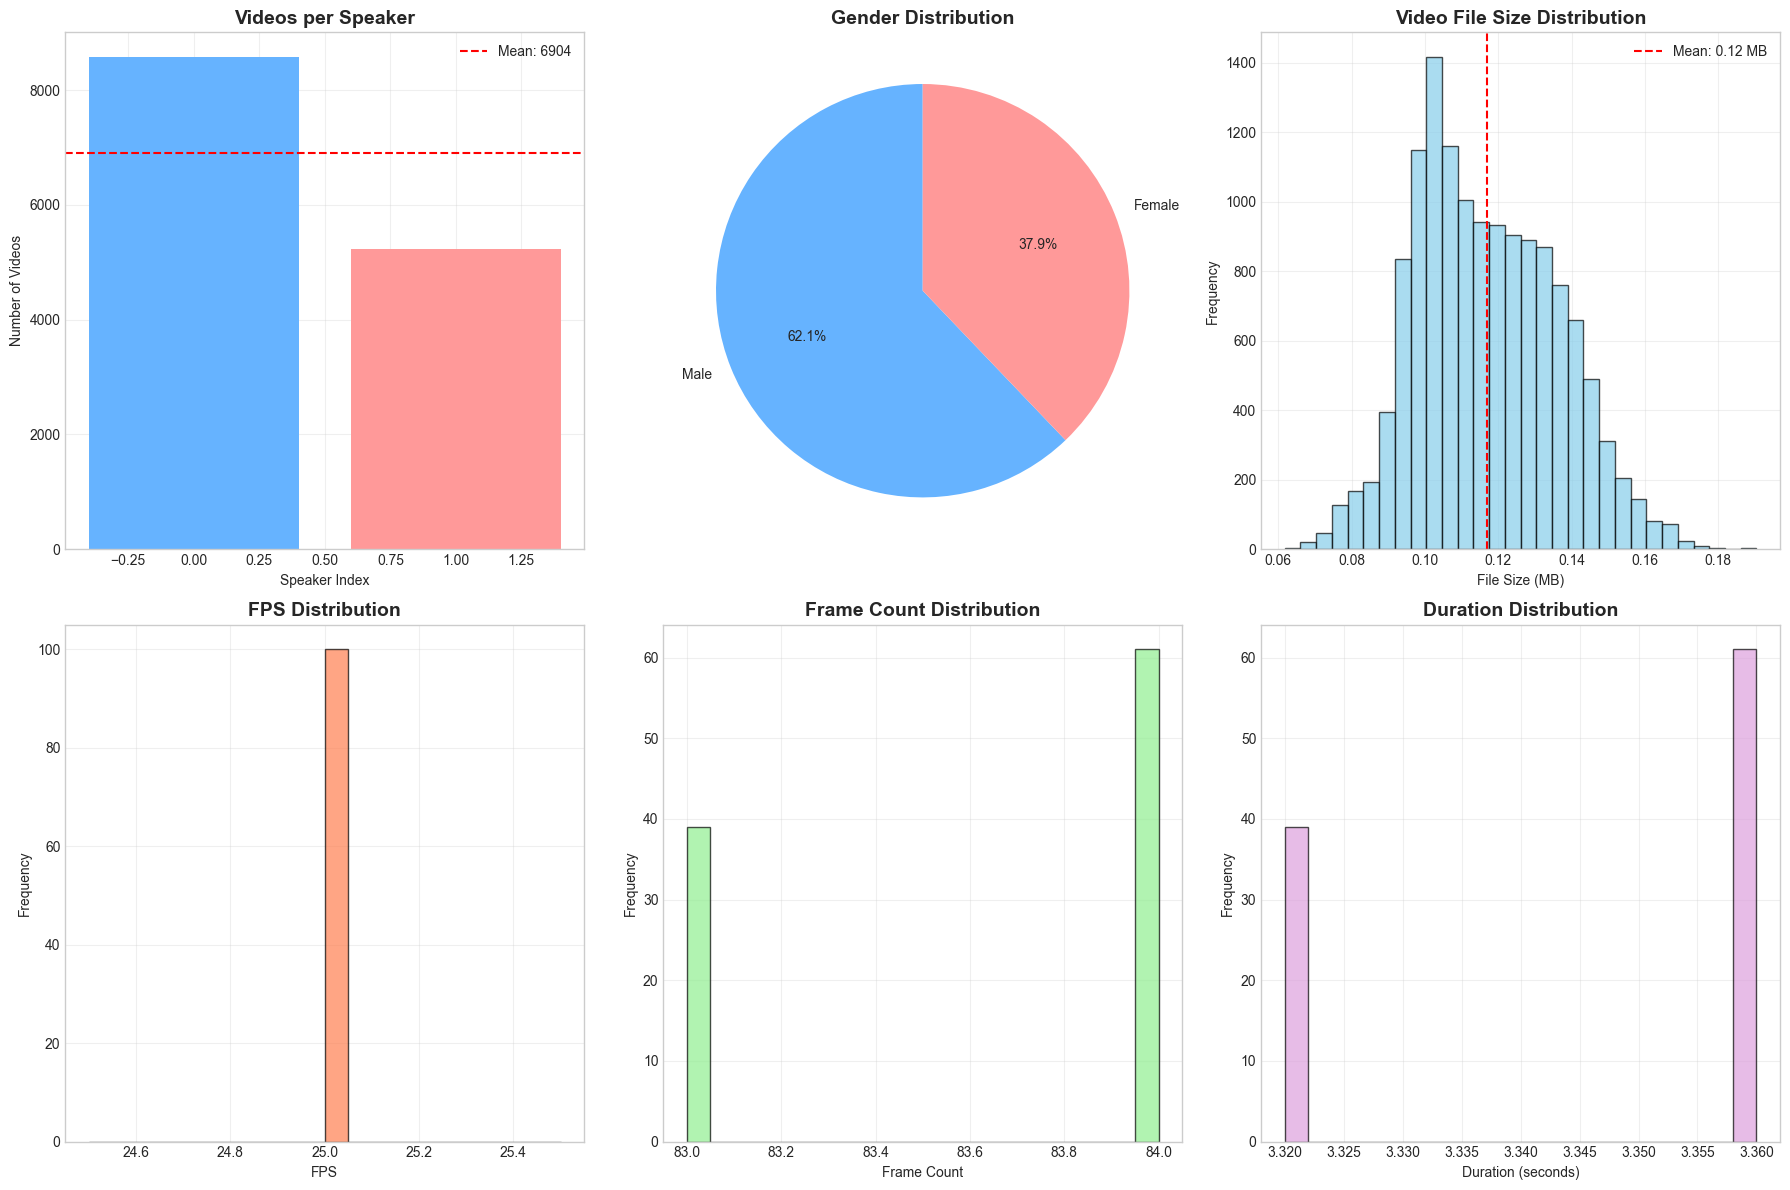

Visualization saved as 'lumina_eda_overview.png'


In [21]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Videos per speaker
speaker_data = speaker_counts.sort_values('count', ascending=False)
colors = ['#ff9999' if g == 'female' else '#66b3ff' for g in speaker_data['gender']]

axes[0, 0].bar(range(len(speaker_data)), speaker_data['count'], color=colors)
axes[0, 0].axhline(speaker_data['count'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {speaker_data["count"].mean():.0f}')
axes[0, 0].set_xlabel('Speaker Index')
axes[0, 0].set_ylabel('Number of Videos')
axes[0, 0].set_title('Videos per Speaker', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Gender distribution
axes[0, 1].pie(gender_counts.values, labels=[g.capitalize() for g in gender_counts.index], 
              autopct='%1.1f%%', colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0, 1].set_title('Gender Distribution', fontsize=14, fontweight='bold')

# 3. File size distribution
axes[0, 2].hist(video_df['file_size_mb'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(video_df['file_size_mb'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {video_df["file_size_mb"].mean():.2f} MB')
axes[0, 2].set_xlabel('File Size (MB)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Video File Size Distribution', fontsize=14, fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. FPS distribution
axes[1, 0].hist(video_properties['fps'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('FPS')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('FPS Distribution', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 5. Frame count distribution
axes[1, 1].hist(video_properties['frame_count'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Frame Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Frame Count Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# 6. Duration distribution
axes[1, 2].hist(video_properties['duration'], bins=20, color='plum', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Duration (seconds)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Duration Distribution', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lumina_eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'lumina_eda_overview.png'")

## 7. Sample Frame Visualization

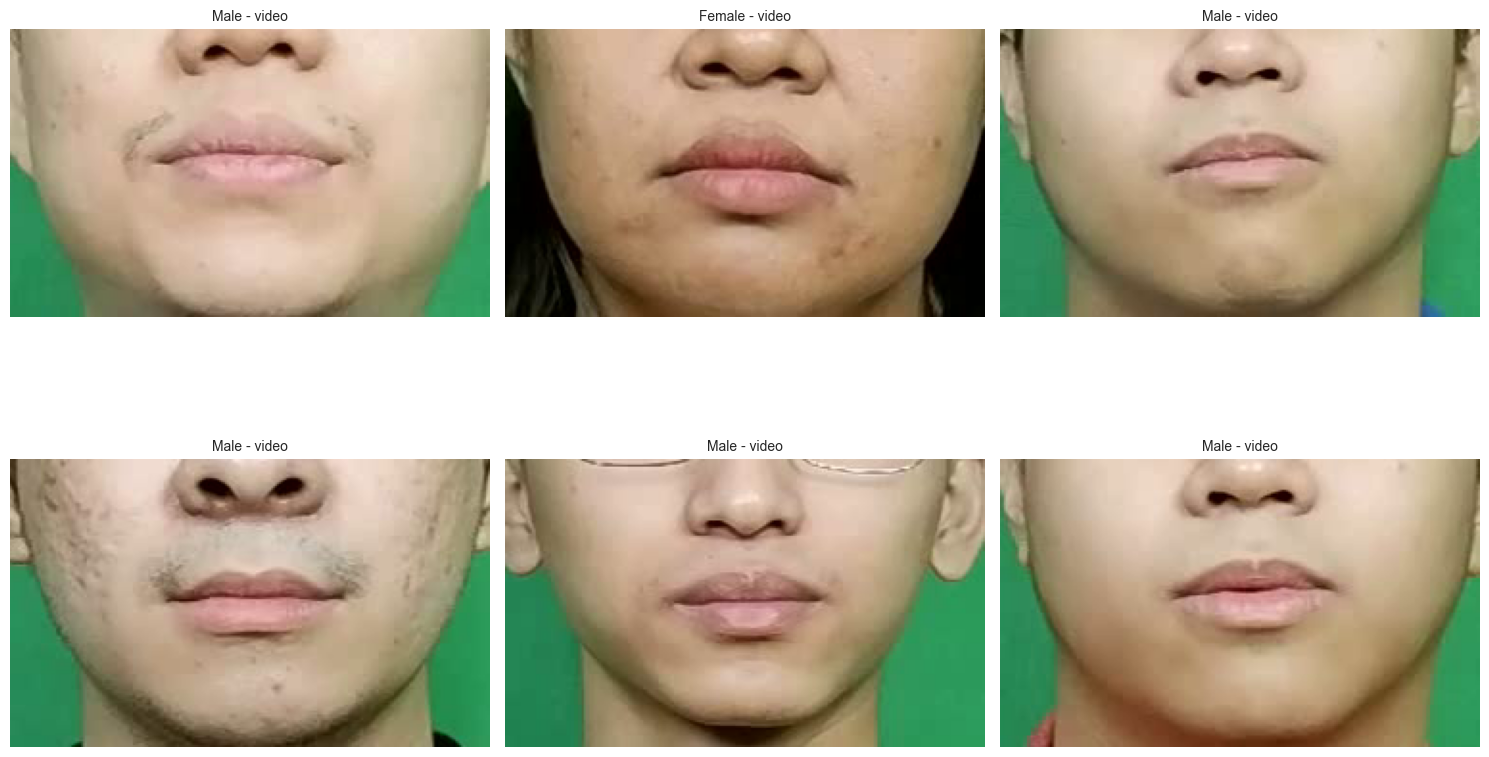

Sample frames saved as 'sample_frames.png'


In [22]:
# Visualize sample frames from random videos
sample_for_viz = video_df.sample(n=min(6, len(video_df)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (i, row) in enumerate(sample_for_viz.iterrows()):
    if idx >= 6:
        break
    
    cap = cv2.VideoCapture(row['filepath'])
    ret, frame = cap.read()
    
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(frame_rgb)
        axes[idx].set_title(f"{row['gender'].capitalize()} - {row['speaker_id']}", fontsize=10)
        axes[idx].axis('off')
    
    cap.release()

plt.tight_layout()
plt.savefig('sample_frames.png', dpi=300, bbox_inches='tight')
plt.show()

print("Sample frames saved as 'sample_frames.png'")

# Exploratory Data Analysis (EDA) Summary

---

### 1. Speaker & Gender Distribution
* **Observation:** The dataset contains **13,808 videos** from 2 speakers (1 Male, 1 Female).
* **Distribution:** Significant imbalance with **62.1% Male** and **37.9% Female** samples.
* **Impact:** Risk of model bias where the network learns speaker-specific features (stubble, jawline) instead of generic visemes.
* **Action:** Apply **stratified splitting** and aggressive **spatial augmentation** (rotation, brightness shifts) to decouple speaker identity from lip movement.


### 2. Temporal Consistency (FPS & Duration)
* **Observation:** The dataset is exceptionally uniform.
    * **FPS:** 25.00 (Constant)
    * **Frame Count:** Fixed at 84 frames per video.
    * **Duration:** $\approx 3.34$ seconds per clip.
* **Impact:** Simplifies the **BGM (Bi-GRU + Mamba)** sequence modeling significantly.
* **Action:** We can utilize **efficient batch processing** without the need for complex padding or masking, as the temporal dimension ($T=84$) is consistent across the entire corpus.

### 3. Spatial Properties & ROI
* **Observation:** Resolution is fixed at **250×150**, pre-cropped to the mouth area.
* **Impact:** While the ROI is focused, background noise (green screen) and static facial features (skin texture, scars) are present.
* **Action:** * Implement **Grayscale conversion** to remove color bias.
    * Apply **Random Cropping ($112 \times 112$)** during training to force the CNN backbone to prioritize high-contrast lip boundaries.

